# ISTAT housing crowding: densita' abitativa media per titolo di godimento

Supporto analitico minimo per una prima discussion `Analisi`.

- **Obiettivo**: confrontare la densita' media di componenti per 100 mq tra abitazioni in affitto e di proprieta'.
- **Dati**: mart `mart_crowding_tenure_italy` (ISTAT dataflow 33_179).
- **Orizzonte usato qui**: serie annuale 2004-2024.
- **Nota**: questa metrica non coincide con il tasso standard di sovraffollamento europeo.

In [ ]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

def find_workspace_root(start: Path) -> Path:
    # Sale dalla posizione corrente finche' non trova dataset-incubator
    candidate = start.resolve()
    if candidate.is_file():
        candidate = candidate.parent
    for _ in range(15):
        if (candidate / 'dataset-incubator').exists():
            return candidate
        parent = candidate.parent
        if parent == candidate:
            break
        candidate = parent
    raise RuntimeError(f'Workspace root non trovato (partito da {start})')

WORKSPACE_ROOT = find_workspace_root(Path.cwd())
parquet_path = WORKSPACE_ROOT / 'dataset-incubator' / 'out' / 'data' / 'mart' / 'istat_housing_crowding' / '2024' / 'mart_crowding_tenure_italy.parquet'

if not parquet_path.exists():
    raise FileNotFoundError(f"Mart non trovato: {parquet_path.resolve()}")

con = duckdb.connect()


In [5]:
query = """
SELECT
    anno,
    titolo_godimento,
    componenti_per_100mq
FROM read_parquet(?)
ORDER BY anno ASC, titolo_godimento DESC
"""

df_res = con.execute(query, [str(parquet_path)]).df()
df_pivot = df_res.pivot(index='anno', columns='titolo_godimento', values='componenti_per_100mq')
df_pivot['diff_rent_prop'] = df_pivot['rent'] - df_pivot['property']
df_pivot.tail(5)

titolo_godimento,property,rent,diff_rent_prop
anno,,,
2020,2.5,3.1,0.6
2021,2.4,3.1,0.7
2022,2.4,3.1,0.7
2023,2.4,3.1,0.7
2024,2.4,3.0,0.6


### Vista rapida

Il grafico rende piu leggibile l'andamento nel tempo della densita' abitativa media tra affitto e proprieta'.

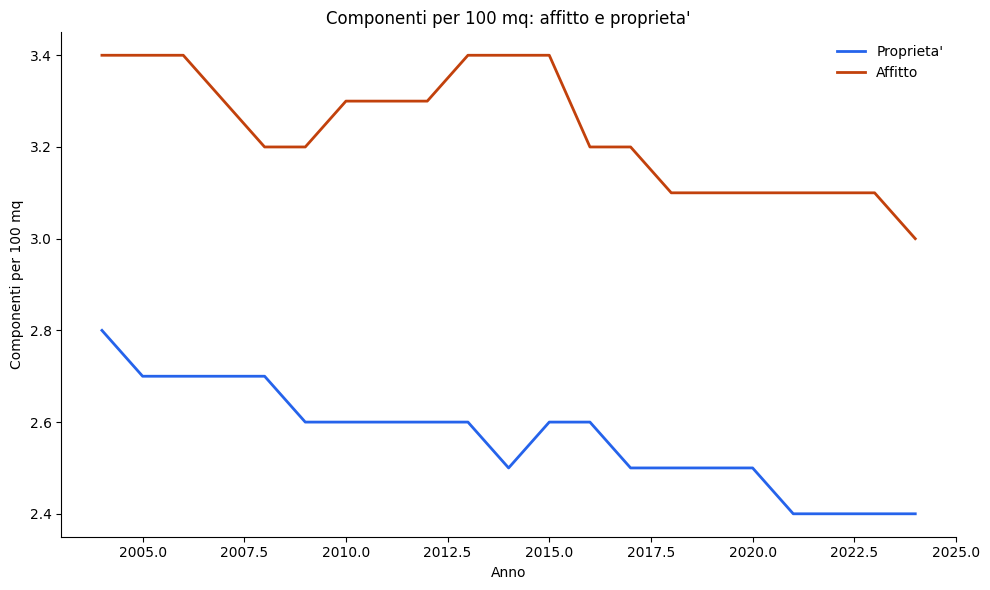

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_pivot.index, df_pivot['property'], label="Proprieta'", color='#2563eb', linewidth=2)
ax.plot(df_pivot.index, df_pivot['rent'], label='Affitto', color='#c2410c', linewidth=2)
ax.set_title("Componenti per 100 mq: affitto e proprieta'")
ax.set_xlabel('Anno')
ax.set_ylabel('Componenti per 100 mq')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [7]:
spotlight_years = [2004, 2024]
spotlight = df_pivot.loc[df_pivot.index.isin(spotlight_years), ['property', 'rent', 'diff_rent_prop']]
spotlight

titolo_godimento,property,rent,diff_rent_prop
anno,,,
2004,2.8,3.4,0.6
2024,2.4,3.0,0.6


### Caveat

- **Dato campionario**: fonte ISTAT EU-SILC.
- **Densita' vs sovraffollamento**: componenti per 100 mq, non stanze per persona.
- **Composizione familiare**: qui non distinguiamo ancora per tipo di nucleo o presenza di figli.
- **Perimetro**: questa e' una prima vista nazionale e descrittiva, non una misura completa di disagio abitativo.